# Project 1: Advanced EDA & Feature Engineering
**DecodeLabs Data Science Industrial Training Kit — Batch 2026**

**Dataset:** `Dataset_for_Data_Analytics.xlsx` — 1,200 e-commerce order records, 14 columns.

**Goal:** Transform raw data into a mathematically clean dataset ready for machine learning by:
1. Handling missing values with statistical imputation
2. Identifying and neutralizing outliers (Z-Score / IQR)
3. Engineering at least 3 new predictive features

> If running in **Google Colab**, run the "Colab setup" cell below to upload the file.
> If running in **Jupyter (local)**, just place the xlsx file in the same folder as this notebook and skip that cell.


## 0. Setup — Colab only (skip this cell in local Jupyter)

In [1]:
# Run this cell ONLY if you are in Google Colab.
# It lets you upload the dataset from your computer.
try:
    import google.colab
    from google.colab import files
    uploaded = files.upload()  # choose Dataset_for_Data_Analytics.xlsx when prompted
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    # Not running in Colab -> assume the file is alongside this notebook
    DATA_PATH = "Dataset_for_Data_Analytics.xlsx"

print("Using data file:", DATA_PATH)


Using data file: Dataset_for_Data_Analytics.xlsx


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


## 2. Load the data

In [3]:
df = pd.read_excel(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


## 3. Initial EDA
Basic statistics and a missing-value audit before we touch anything.

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,1200,1200,ORD200000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1200,NaN,NaN,NaN,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
CustomerID,1200,1189,C98474,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1200,7,Printer,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1200.0,NaN,NaN,NaN,2.945833,1.0,2.0,3.0,4.0,5.0,1.407557
UnitPrice,1200.0,NaN,NaN,NaN,356.41275,11.39,186.0625,364.21,521.57,699.93,197.177146
ShippingAddress,1200,655,533 Main St,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,1200,5,Online,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderStatus,1200,5,Cancelled,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackingNumber,1200,1200,TRK37947903,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Missing-value audit (per the Missing Data Decision Matrix from the training kit)
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_report


,missing_count,missing_pct
CouponCode,309,25.75


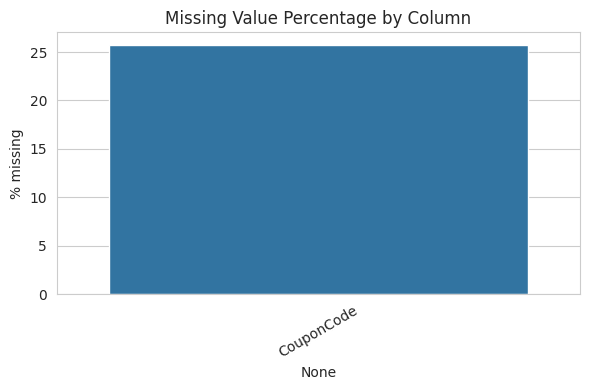

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(x=missing_report.index, y=missing_report["missing_pct"])
plt.ylabel("% missing")
plt.title("Missing Value Percentage by Column")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. Handling Missing Values

Only **`CouponCode`** has missing values (~25.75%). This is a *categorical* column, and a
blank value here almost certainly means **no coupon was applied** to that order — it is
not "missing at random" numeric data. So instead of a numeric imputation (mean/median/KNN),
the statistically correct move is to encode the missingness itself as an explicit category.

This is the key judgment call the kit asks for: **don't guess — apply structural logic**.
We also demonstrate the general-purpose numeric imputation functions (mean/median/KNN) so
the same pipeline can be reused if a future dataset has missing numeric fields.

In [8]:
from sklearn.impute import KNNImputer

def impute_numeric_column(series: pd.Series, method: str = "median") -> pd.Series:
    """Reusable statistical imputation helper (Mean / Median / KNN) for numeric columns."""
    if series.isna().sum() == 0:
        return series
    if method == "mean":
        return series.fillna(series.mean())
    elif method == "median":
        return series.fillna(series.median())
    elif method == "knn":
        imputer = KNNImputer(n_neighbors=5)
        return pd.Series(imputer.fit_transform(series.to_frame())[:, 0], index=series.index)
    else:
        raise ValueError("method must be 'mean', 'median', or 'knn'")

# Demonstration only — none of the numeric columns in this dataset have missing values,
# so this function is a no-op here, but it documents the approach required by the brief.
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
for c in numeric_cols:
    df[c] = impute_numeric_column(df[c], method="median")

print("Remaining missing values in numeric columns:")
print(df[numeric_cols].isna().sum())


Remaining missing values in numeric columns:
Quantity       0
UnitPrice      0
ItemsInCart    0
TotalPrice     0
dtype: int64


In [9]:
# Categorical imputation: encode missing CouponCode as an explicit category
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

print(df["CouponCode"].value_counts())
print("\nMissing values left in the whole dataframe:", df.isna().sum().sum())


CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

Missing values left in the whole dataframe: 0


## 5. Outlier Detection & Treatment

We apply **both** methods required by the brief — Z-Score and IQR — on the key numeric
columns (`Quantity`, `UnitPrice`, `ItemsInCart`, `TotalPrice`), compare what each one flags,
and then neutralize genuine outliers using IQR-based **capping (Winsorization)** rather than
row deletion, so we don't lose data volume.

In [10]:
from scipy import stats

def zscore_outliers(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return a boolean mask of Z-score outliers."""
    z = np.abs(stats.zscore(series, nan_policy="omit"))
    return z > threshold

def iqr_bounds(series: pd.Series, k: float = 1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

outlier_summary = {}
for col in numeric_cols:
    z_mask = zscore_outliers(df[col])
    lower, upper = iqr_bounds(df[col])
    iqr_mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary[col] = {
        "z_score_outliers": int(z_mask.sum()),
        "iqr_outliers": int(iqr_mask.sum()),
        "iqr_lower_bound": round(lower, 2),
        "iqr_upper_bound": round(upper, 2),
    }

pd.DataFrame(outlier_summary).T


,z_score_outliers,iqr_outliers,iqr_lower_bound,iqr_upper_bound
Quantity,0.0,0.0,-1.00,7.00
UnitPrice,0.0,0.0,-317.20,1024.83
ItemsInCart,0.0,0.0,-0.50,11.50
TotalPrice,0.0,8.0,-1341.41,3330.41


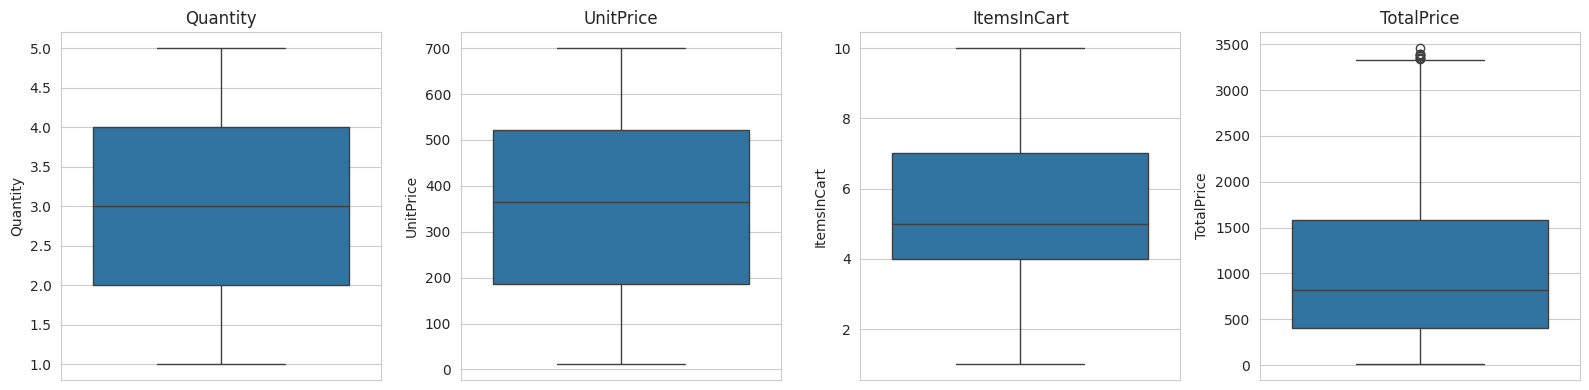

In [11]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [12]:
# Neutralize outliers via IQR capping (Winsorization) — preserves row count.
def cap_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    lower, upper = iqr_bounds(series, k)
    return series.clip(lower=lower, upper=upper)

for col in numeric_cols:
    df[col] = cap_outliers_iqr(df[col])

print("Outlier treatment complete. Row count preserved:", len(df))


Outlier treatment complete. Row count preserved: 1200


## 6. Feature Engineering

We engineer several new predictive features from the existing columns (the brief asks for
at least 3 — five are included here for a stronger portfolio piece):

1. **`OrderMonth`** / **`OrderDayOfWeek`** — seasonality signals extracted from `Date`
2. **`IsWeekend`** — binary flag for weekend orders
3. **`AvgItemPrice`** — `TotalPrice / Quantity`, a normalized per-unit price signal
4. **`CartUtilization`** — `Quantity / ItemsInCart`, how much of the cart was actually ordered
5. **`HasCoupon`** — binary flag derived from `CouponCode`

In [13]:
df["OrderMonth"] = df["Date"].dt.month
df["OrderDayOfWeek"] = df["Date"].dt.dayofweek  # 0 = Monday
df["IsWeekend"] = df["OrderDayOfWeek"].isin([5, 6]).astype(int)

df["AvgItemPrice"] = (df["TotalPrice"] / df["Quantity"]).round(2)

df["CartUtilization"] = (df["Quantity"] / df["ItemsInCart"]).round(2)

df["HasCoupon"] = (df["CouponCode"] != "No Coupon").astype(int)

new_features = ["OrderMonth", "OrderDayOfWeek", "IsWeekend", "AvgItemPrice", "CartUtilization", "HasCoupon"]
df[new_features].head()


,OrderMonth,OrderDayOfWeek,IsWeekend,AvgItemPrice,CartUtilization,HasCoupon
0,1,2,0,570.62,0.71,1
1,8,4,0,151.35,0.67,1
2,2,1,0,550.68,0.62,1
3,10,6,1,273.19,0.20,1
4,5,3,0,626.01,0.50,1


## 7. Categorical Encoding & Multicollinearity Check

One-hot encode the low-cardinality categorical columns (per the "Categorical Translation
into Coordinate Space" principle — avoids injecting false ordinal distance), then check the
correlation matrix for multicollinearity among numeric predictors.

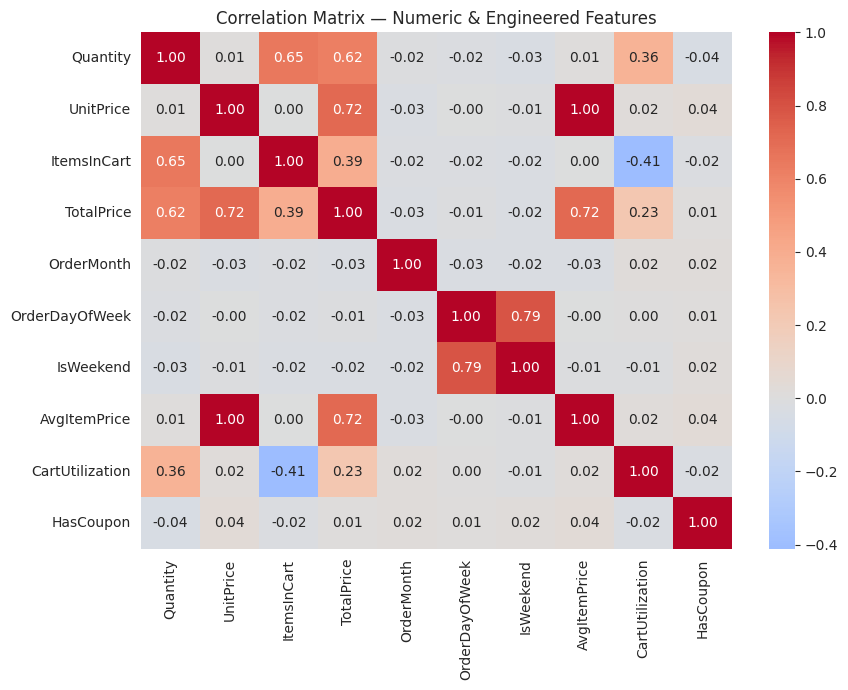

In [14]:
categorical_cols = ["Product", "PaymentMethod", "OrderStatus", "ReferralSource", "CouponCode"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

corr_cols = numeric_cols + new_features
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric & Engineered Features")
plt.tight_layout()
plt.show()


## 8. Export the Cleaned Dataset

In [15]:
output_path = "cleaned_dataset.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
df.shape


Cleaned dataset saved to: cleaned_dataset.csv


(1200, 20)

## 9. Summary

| Step | What we did |
|---|---|
| Missing values | `CouponCode` (25.75% missing) recoded as explicit `"No Coupon"` category; reusable mean/median/KNN helper included for numeric columns |
| Outliers | Compared Z-Score vs IQR flags on `Quantity`, `UnitPrice`, `ItemsInCart`, `TotalPrice`; neutralized via IQR capping (no rows dropped) |
| Feature engineering | Added `OrderMonth`, `OrderDayOfWeek`, `IsWeekend`, `AvgItemPrice`, `CartUtilization`, `HasCoupon` |
| Encoding | One-hot encoded categorical columns to avoid false ordinal distance |
| Output | `cleaned_dataset.csv` — ready for downstream ML modeling |
